***

## DL & GEN AI - 21st July 2026

## PRACTICAL 1 : Activation Functions 

***

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x = np.linspace(-16, 16, 1000)

print("Libraries imported successfully.")

Libraries imported successfully.


## - common plotting function

In [2]:
def plot_function_and_derivative(name, function, derivative, x_values=x):
    y = function(x_values)
    dy = derivative(x_values)

    plt.figure(figsize=(9, 5))
    plt.plot(x_values, y, label="Original function: f(z)", linewidth=2)
    plt.plot(x_values, dy, label="Derivative: f'(z)", linewidth=2)
    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)
    plt.xlabel("Input z")
    plt.ylabel("Output")
    plt.title(name)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()
    

## 1] binary step

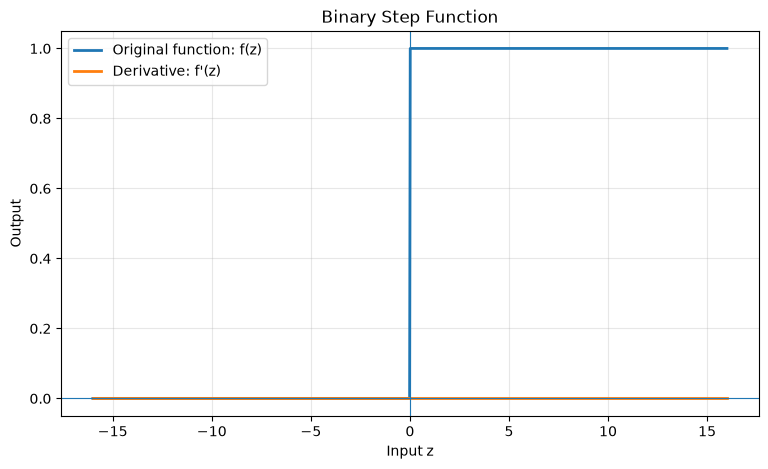

In [3]:
def binary_step(z):
    return np.where(z >= 0, 1.0, 0.0)

def binary_step_derivative(z):
    # Zero is used for visualization.
    # Mathematically, the derivative is undefined at z = 0.
    return np.zeros_like(z)

plot_function_and_derivative(
    "Binary Step Function",
    binary_step,
    binary_step_derivative
)

## 2] linear or indentity function

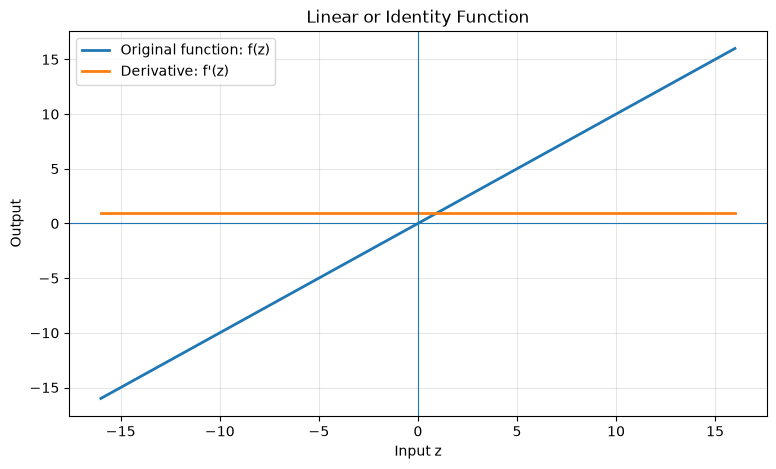

In [4]:
def linear(z):
    return z

def linear_derivative(z):
    return np.ones_like(z)

plot_function_and_derivative(
    "Linear or Identity Function",
    linear,
    linear_derivative
)

## 3] sigmoid function

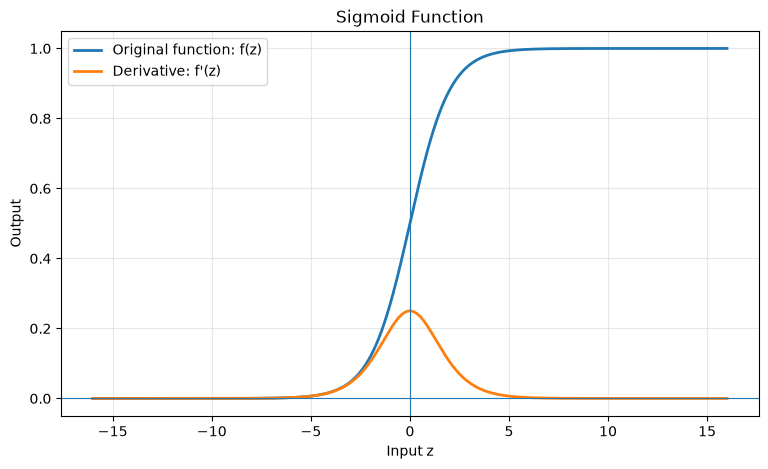

In [5]:
def sigmoid(z):
    z = np.asarray(z, dtype=float)
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1.0 - s)

plot_function_and_derivative(
    "Sigmoid Function",
    sigmoid,
    sigmoid_derivative
)

## 4] hyperbolic tangent (tanh) function

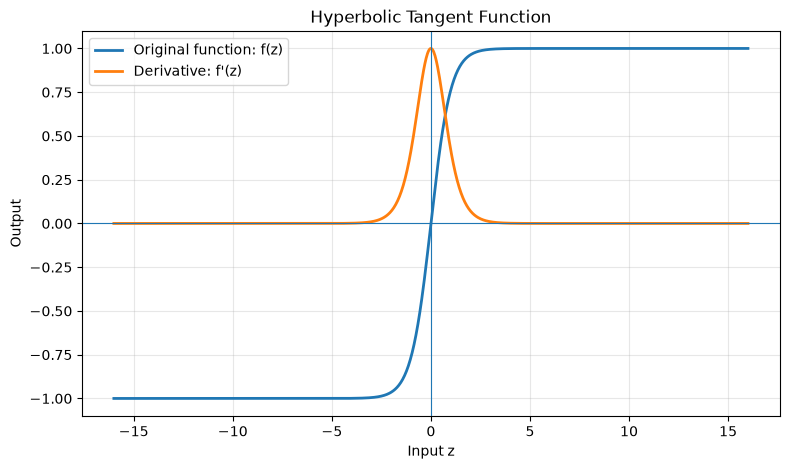

In [6]:
def tanh_function(z):
    return np.tanh(z)

def tanh_derivative(z):
    return 1.0 - np.tanh(z)**2

plot_function_and_derivative(
    "Hyperbolic Tangent Function",
    tanh_function,
    tanh_derivative
)

## 5] rectified linear unit (ReLU) function

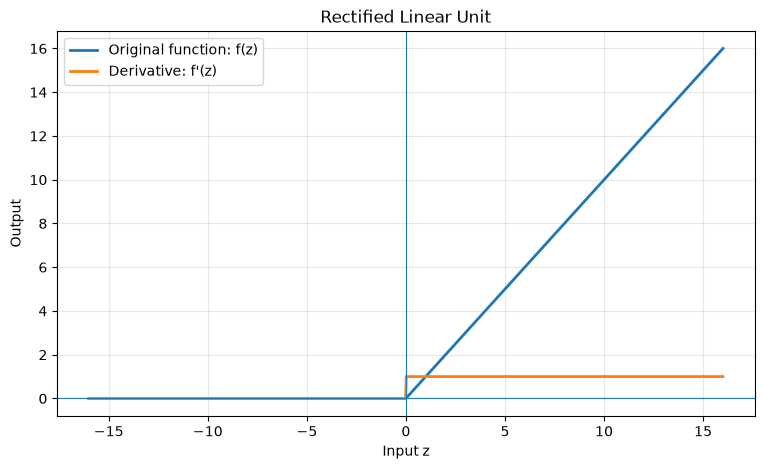

In [7]:
def relu(z):
    return np.maximum(0.0, z)

def relu_derivative(z):
    return np.where(z > 0, 1.0, 0.0)

plot_function_and_derivative(
    "Rectified Linear Unit",
    relu,
    relu_derivative
)

## 6] leaky ReLU function

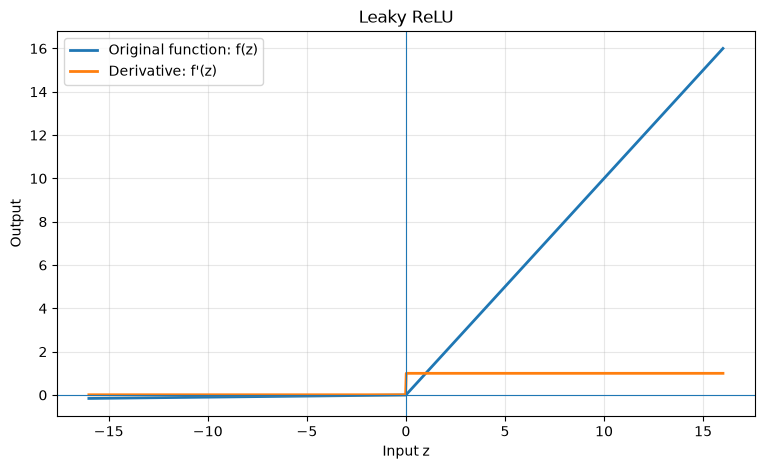

In [8]:
alpha = 0.01

def leaky_relu(z):
    return np.where(z >= 0, z, alpha * z)

def leaky_relu_derivative(z):
    return np.where(z > 0, 1.0, alpha)

plot_function_and_derivative(
    "Leaky ReLU",
    leaky_relu,
    leaky_relu_derivative
)


## 7] exponential linear unit (ELU) function

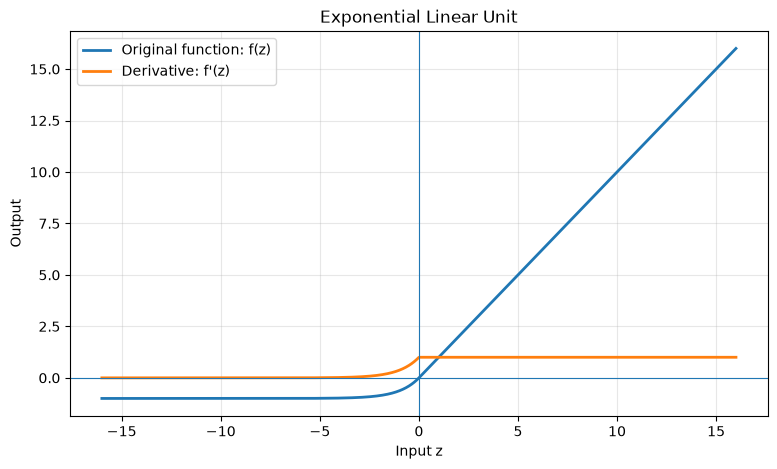

In [9]:
elu_alpha = 1.0

def elu(z):
    return np.where(z > 0, z, elu_alpha * (np.exp(z) - 1.0))

def elu_derivative(z):
    return np.where(z > 0, 1.0, elu_alpha * np.exp(z))

plot_function_and_derivative(
    "Exponential Linear Unit",
    elu,
    elu_derivative
)

## 8] softplus function

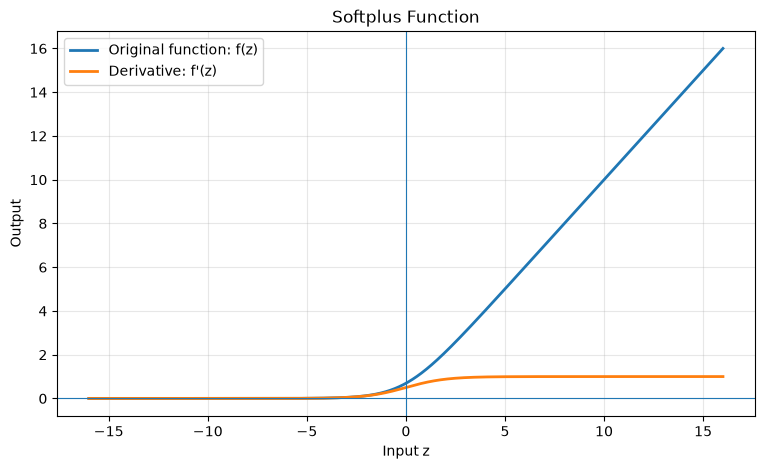

In [10]:
def softplus(z):
    return np.log1p(np.exp(z))

def softplus_derivative(z):
    return sigmoid(z)

plot_function_and_derivative(
    "Softplus Function",
    softplus,
    softplus_derivative
)

## 9] swish or SiLU function

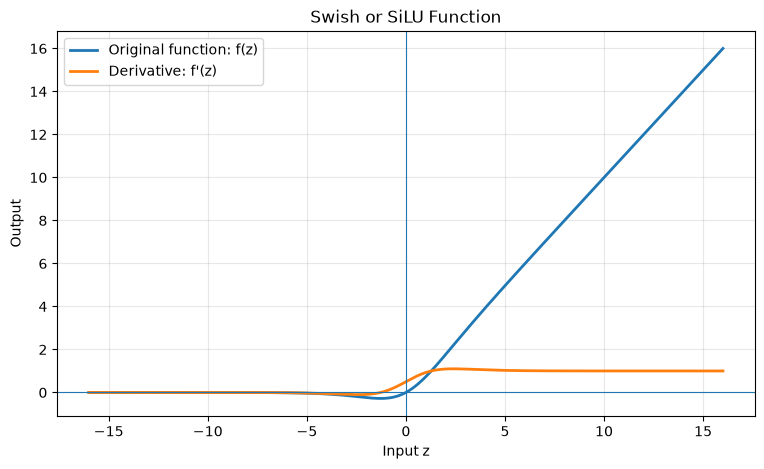

In [11]:
def swish(z):
    return z * sigmoid(z)

def swish_derivative(z):
    s = sigmoid(z)
    return s + z * s * (1.0 - s)

plot_function_and_derivative(
    "Swish or SiLU Function",
    swish,
    swish_derivative
)

## 10] GELU function

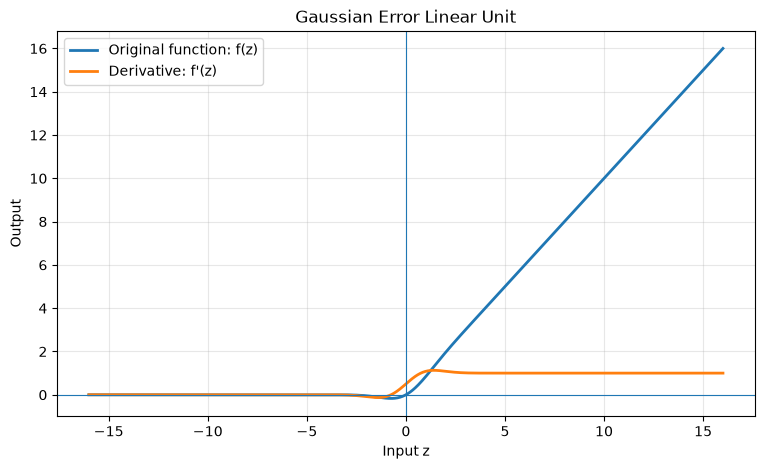

In [12]:
def normal_cdf(z):
    values = np.vectorize(math.erf)(z / np.sqrt(2.0))
    return 0.5 * (1.0 + values)

def normal_pdf(z):
    return np.exp(-0.5 * z**2) / np.sqrt(2.0 * np.pi)

def gelu(z):
    return z * normal_cdf(z)

def gelu_derivative(z):
    return normal_cdf(z) + z * normal_pdf(z)

plot_function_and_derivative(
    "Gaussian Error Linear Unit",
    gelu,
    gelu_derivative
)

## 11] softmax function

In [13]:
def softmax(logits):
    logits = np.asarray(logits, dtype=float)
    shifted = logits - np.max(logits)
    exp_values = np.exp(shifted)
    return exp_values / exp_values.sum()

def softmax_jacobian(logits):
    probabilities = softmax(logits)
    return np.diag(probabilities) - np.outer(probabilities, probabilities)
    

In [14]:
logits = np.array([2.0, 1.0, 0.1])
probabilities = softmax(logits)
jacobian = softmax_jacobian(logits)

print("Input logits:", logits)
print("Softmax probabilities:", probabilities)
print("Sum of probabilities:", probabilities.sum())
print("\nSoftmax derivative matrix:")
print(jacobian)


Input logits: [2.  1.  0.1]
Softmax probabilities: [0.65900114 0.24243297 0.09856589]
Sum of probabilities: 1.0

Softmax derivative matrix:
[[ 0.22471864 -0.1597636  -0.06495503]
 [-0.1597636   0.18365923 -0.02389562]
 [-0.06495503 -0.02389562  0.08885066]]


***

## - comparasion of common activation functions

***